# **COMPLETE CELL CLUSTERING LOOP FOR SINGLE CELL RNA SEQUENCING ANALYSIS**

Author: Holly Vose

Last Updated: 7/21/26

In [1]:
#STEP 1: IMPORTS
#Load this first

import warnings
import scanpy as sc
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import doubletdetection
import soupx
import harmonypy as hm
import decoupler
import scvi
from IPython.display import clear_output 
import re
import os

warnings.filterwarnings('ignore')

/projects/hvose@xsede.org/software/anaconda/envs/jupyter_scrna/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#This cell corresponds to the first of the fixed scRNA experiments (treatment, 2/9/2026)

experiment = "fiber"

filtered_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample1/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample2/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample3/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample4/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample5/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample6/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample7/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample8/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample9/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample10/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample11/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample12/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample13/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample14/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample15/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample16/count/sample_filtered_feature_bc_matrix.h5"}

raw_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample1/count/sample_raw_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample2/count/sample_raw_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample3/count/sample_raw_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample4/count/sample_raw_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample5/count/sample_raw_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample6/count/sample_raw_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample7/count/sample_raw_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample8/count/sample_raw_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample9/count/sample_raw_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample10/count/sample_raw_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample11/count/sample_raw_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample12/count/sample_raw_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample13/count/sample_raw_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample14/count/sample_raw_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample15/count/sample_raw_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample16/count/sample_raw_feature_bc_matrix.h5"}

In [3]:
#STEP 3: GENERATE ANNDATA OBJECT WITH SAMPLES
#For each item in our dictionary, we want to read in the info, make the cells unique, and then combine them into a single object
#Additionally, we are going to add an "infection type" (i_type) column that specifies the infection type based on the loaded sample.
#note: scvi-tools on CPU can take up to 6.5 hrs to properly finish!!!
adatas = {}
adatas_raw = {}

for sample_id, filename in filtered_samples.items():
    sample_adata = sc.read_10x_h5(filename)
    #sample_adata = sc.read_10x_mtx(filename,compressed=True)
    sample_adata.var_names_make_unique()
    sample_adata.var["mt"] = sample_adata.var_names.str.startswith("mt-")
    sc.pp.calculate_qc_metrics(
        sample_adata, qc_vars=["mt"], inplace=True, log1p=True
    )
    sample_adata_mid_filter = sample_adata[sample_adata.obs['pct_counts_mt']<5]
    print(f"finished mt removal for sample id {sample_id}")
    sc.pp.filter_genes(sample_adata_mid_filter,min_cells=10)
    sc.pp.filter_cells(sample_adata_mid_filter,min_genes=30)
    #sc.pp.highly_variable_genes(sample_adata_mid_filter,n_top_genes=2000, subset=True, flavor="seurat_v3")
    print(f"new adata shape is {sample_adata_mid_filter.shape}\nNow calculating scrublets for {sample_id}")
    sc.pp.scrublet(sample_adata_mid_filter)
    sc.pp.pca(sample_adata_mid_filter)
    sc.pp.neighbors(sample_adata_mid_filter)
    sc.tl.umap(sample_adata_mid_filter)

    # scvi.model.SCVI.setup_anndata(sample_adata_mid_filter)
    # vae = scvi.model.SCVI(sample_adata_mid_filter)
    # vae.train()

    # solo = scvi.external.SOLO.from_scvi_model(vae)
    # solo.train()

    # df_doublet = solo.predict()
    # df_doublet['prediction'] = solo.predict(soft=False)

    #takes out the extra annotations added by solo
    # df_doublet.index = df_doublet.index.map(lambda x: x[:-2])

    #creates a difference category for adjusting doublet values based on gradients
    # df_doublet['difference'] = df_doublet.doublet - df_doublet.singlet

    # doublets = df_doublet[(df_doublet['prediction'] == 'doublet') & (df_doublet.difference > 1)]

    # sample_adata.obs['doublet_predict'] = sample_adata.obs.index.isin(doublets.index)

    # sample_adata = sample_adata[~sample_adata.obs.doublet_predict]
    
    adatas[sample_id] = sample_adata_mid_filter
    print(sample_adata)
    print(f"finished processing for sample {sample_id}")

    # print(f"finished processing for sample id {sample_id}")


finished mt removal for sample id sample_1
new adata shape is (9437, 13848)
Now calculating scrublets for sample_1
AnnData object with n_obs × n_vars = 9916 × 19059
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
finished processing for sample sample_1
finished mt removal for sample id sample_2
new adata shape is (7832, 13491)
Now calculating scrublets for sample_2
AnnData object with n_obs × n_vars = 8117 × 19059
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_

In [4]:
for keys,adata_vals in adatas.items():
    val = re.search(r"sample_(\d+)",keys).group(1)
    match val:
            case val if 1<=int(val)<=5:
                adata_vals.obs["treatment"] = "no_fiber"
            case val if 6<=int(val)<=10:
                adata_vals.obs["treatment"] = "amp"
            case _:
                adata_vals.obs["treatment"] = "5DPI"

In [ ]:
#gene specificity between samples

all_genes = {}
for keys in adatas.keys():
    for gene in list(adatas[keys].var_names):
        if gene not in all_genes:
            all_genes[gene] = [keys]
        else:
            all_genes[gene].append(keys)

for genes,vals in all_genes.items():
    if len(vals) == 1:
        print(f"{genes} is specific to {vals}")
    elif vals[-1] == "sample_5":
        print(f"{genes} is seen in no_fiber samples {vals}")
    elif (vals[0] == "sample_6") and (vals[-1] == "sample_10"):
        print(f"{genes} is seen in amp samples {vals}")
    elif (vals[0] == "sample_11") and (vals[-1] == "sample_16"):
        print(f"{genes} is seen in 5DPI samples {vals}")

#find all specific genes using a regex match
r = re.compile("M.+(\d+)")
newlist = list(filter(r.match, adatas["sample_1"].var_names))
print(sorted(newlist))

In [5]:
#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

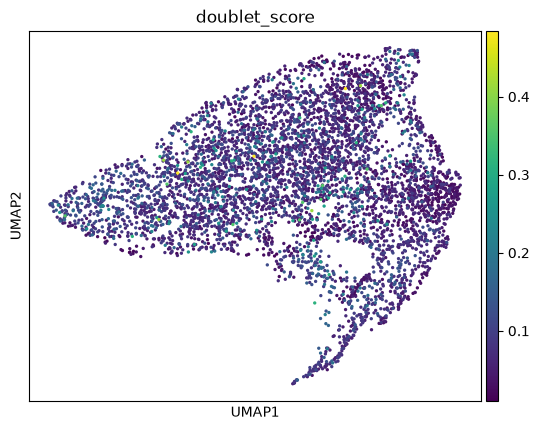

Current cell count: 5196
Previous cell count: 5196
what doublet score to threshold below? Put Back to revert to previous value(Put None for no thresholding)


KeyboardInterrupt: Interrupted by user

In [6]:
%matplotlib inline
#attempting a looped clustering cell: i hope this works
#THINGS TO ADD
# - error handling if a cluster that isn't valid is inputted, don't crash the loop
# - add "save states" for coming back to unfinished work

finished = False
marker_genes = {
    "T Cells": ["Cd3e"],
    "B Cells": ["Cd19", "Cd74"],
    "Absorptive Colonocytes": ["Slc26a3","Aqp4","Aqp8","Cyp2c55","Car1"],
    "Enteroendocrine Cells": ["Neurod1","Chga","Chgb"],
    "Stem Cells": ["Lgr5","Nox1","Ascl2"],
    "Transit Amplifying Cells": ["Mki67","Top2a","Ube2c"],
    "Goblet Cells": ["Muc2","Zg16","Tff3","Spink4"],
    "Tuft Cells": ["Dclk1"],
    "Mast Cells": ["Mcpt1","Mcpt2"]
}
res_list = [0.20, 0.50, 0.75, 1.00]
for keys, adata_vals in adatas.items():
    print(f"SAMPLE ANNOTATION FOR {keys}")
    adata_old_vals = adata_vals.copy()
    while not finished:
        markers = ["Cd3e","Cd19","Cd74","Slc26a3", "Aqp4", "Aqp8", "Cyp2c55", "Car1", "Chga", "Neurod1", "Muc2", "Tff3", "Spink4", "Zg16", "Lgr5", "Ascl2", "Nox1", "Mki67", "Top2a", "Ube2c", "Dclk1","Mcpt1","Mcpt2"]
        clear_output(wait=True)
        print(f"SAMPLE ANNOTATION FOR {keys}")
        sc.pl.umap(adata_vals,color="doublet_score")
        for marker in markers:
            if marker not in list(adata_vals.var_names):
                print(f"WARNING: No {marker} expression at this level of removal.")
                remove_markers.remove(marker)
        #sc.pl.heatmap(adata_vals,markers,groupby=f"leiden_res_{new_res}",figsize=(30,8),swap_axes=True)
        print(f"Current cell count: {adata_vals.n_obs}")
        print(f"Previous cell count: {adata_old_vals.n_obs}")
        print("what doublet score to threshold below? Put Back to revert to previous value(Put None for no thresholding)")
        doublet_remove = input()
        if doublet_remove != "None":
            if doublet_remove == "Back":
                adata_vals = adata_old_vals
            else:
                try:
                    adata_old_vals = adata_vals
                    new_threshold = float(doublet_remove)
                    adata_vals = adata_vals[adata_vals.obs["doublet_score"] < float(doublet_remove)].copy()
                    clear_output(wait=True)
                    print("Calculating new PCA and leiden clusters...")
                    sc.pp.pca(adata_vals)
                    sc.tl.umap(adata_vals)
                except ValueError as e:
                    print("invalid input. try again.")
        else:
            del adata_old_vals
            finished = True
            valid_res = False
            clear_output(wait=True)
            print(f"SAMPLE ANNOTATION FOR {keys}")
            print(f"SAMPLE ID: {keys}")
            sc.tl.leiden(adata_vals, key_added="leiden_res_0.20", resolution=0.20, flavor="igraph")
            sc.pl.umap(adata_vals, color="leiden_res_0.20",legend_loc="on data")
            sc.pl.heatmap(adata_vals,marker_genes,groupby="leiden_res_0.20",figsize=(30,8),swap_axes=True)
            sc.pp.normalize_total(adata_vals)
            sc.pp.log1p(adata_vals)
            plt.show()
            while not valid_res:
                print("would you like to try a different resolution? [Y/N]")
                new_res = input()
                if new_res.upper() == "Y":
                    print("please input a new resolution to try:")
                    use_res = input()
                    clear_output(wait=True)
                    use_res = f"{float(use_res):4.2f}"
                    sc.tl.leiden(adata_vals, key_added=f"leiden_res_{use_res}", resolution=float(use_res), flavor="igraph")
                    sc.pl.umap(adata_vals, color=f"leiden_res_{use_res}", legend_loc="on data")
                    sc.pl.heatmap(adata_vals,marker_genes,groupby=f"leiden_res_{use_res}",figsize=(30,8),swap_axes=True)
                elif new_res.upper() == "N":
                    valid_res = True
                    #generate most differentially expressed genes per cluster
                    clear_output(wait=True)
                    sc.tl.rank_genes_groups(adata_vals, groupby=f"leiden_res_{use_res}", method="wilcoxon")
                    sc.pl.rank_genes_groups_dotplot(adata_vals, groupby=f"leiden_res_{use_res}", standard_scale="var", n_genes=5,dendrogram=False)
                    sc.pl.heatmap(adata_vals,marker_genes,groupby=f"leiden_res_{use_res}",figsize=(30,8),swap_axes=True)
                    sc.pl.umap(adata_vals,color=f"leiden_res_{use_res}",legend_loc="on data")
                    umap_plots = ["Lgr5","Mki67","Muc2","Car1","Cd3e","Dclk1","Chga"]
                    for gene in umap_plots:
                        sc.pl.umap(adata_vals,color=gene)
                else:
                    print("Invalid input. Please enter Y or N.")

    print("Initial guesses for cluster identification")
    cluster_list = adata_vals.obs[f"leiden_res_{use_res}"].cat.categories.tolist()
    while cluster_list != []:
        print("What function would you like to see? [options are umap or id]")
        print(f"Clusters remaining: {cluster_list}")
        curr_func = input()
        if curr_func == "umap":
            print("Which gene would you like to plot?")
            plot_gene = input()
            try:
                sc.pl.umap(adata_vals,color=plot_gene,cmap=ifitm_cmap)
            except KeyError as e:
                print(f"{plot_gene} is not a valid gene. Please try again.")
        elif curr_func == "id":
            print("Cluster to identify:")
            cluster = input()
            if "," in cluster:
                cluster = cluster.split(",")
            print(f"Identity for cluster(s) {cluster}:")
            clus_id = input()
            if type(cluster) == list:
                for num in cluster:
                    adata_vals.obs.loc[adata_vals.obs[f"leiden_res_{use_res}"] == num, 'init_annotation'] = clus_id
                    if num in cluster_list:
                        cluster_list.remove(num)
            else:
                adata_vals.obs.loc[adata_vals.obs[f"leiden_res_{use_res}"] == cluster, 'init_annotation'] = clus_id
                if cluster in cluster_list:
                    cluster_list.remove(cluster)
        else:
            print("invalid command")
    print("exited loop! all init_annotation values recorded.")
    finished = False
    
    plt.close()

In [ ]:
adata = ad.concat(adatas_raw, label="sample")
adata.obs_names_make_unique()